## Simulate RBF-RWKA with different statistical models

In [139]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from metrics import AlignmentMetrics
import seaborn as sns

# Set style for better-looking plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

### Define Statistical Models for Generating Representations

In [140]:
def generate_gaussian(n_samples, dim, mean=0, std=1):
    """
    Generate samples from a Gaussian distribution.
    """
    return torch.randn(n_samples, dim) * std + mean

def generate_mixture_of_gaussians(n_samples, dim, n_components=3, separation=15.0, seed=None):
    """
    Generate samples from a mixture of Gaussians.
    Uses fixed component means (based on seed) to ensure two samples come from same distribution.
    """
    if seed is not None:
        torch.manual_seed(seed)
    
    # Generate component means (these stay the same for both samples)
    component_means = [torch.randn(dim) * separation for _ in range(n_components)]
    
    samples_per_component = n_samples // n_components
    samples = []
    
    for i in range(n_components):
        component_samples = torch.randn(samples_per_component, dim) + component_means[i]
        samples.append(component_samples)
    
    # Add remaining samples to last component
    remainder = n_samples - samples_per_component * n_components
    if remainder > 0:
        samples.append(torch.randn(remainder, dim) + component_means[-1])
    
    return torch.cat(samples, dim=0)

def generate_uniform(n_samples, dim, low=-3, high=3):
    """
    Generate samples from a uniform distribution.
    """
    return torch.rand(n_samples, dim) * (high - low) + low

def generate_laplacian(n_samples, dim, loc=0, scale=1):
    """
    Generate samples from a Laplacian distribution.
    """
    dist = torch.distributions.Laplace(loc, scale)
    return dist.sample((n_samples, dim))

def generate_student_t(n_samples, dim, df=3):
    """
    Generate samples from a Student's t-distribution (heavy-tailed).
    """
    dist = torch.distributions.StudentT(df)
    return dist.sample((n_samples, dim))

def generate_sparse_gaussian(n_samples, dim, sparsity=0.7):
    """
    Generate sparse Gaussian samples (many dimensions are zero).
    """
    samples = torch.randn(n_samples, dim)
    mask = torch.rand(n_samples, dim) > sparsity
    return samples * mask.float()

### Experiment Configuration

In [141]:
# Experiment parameters
n_samples = 1000
dim = 2
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Range of rbf_sigma values to test (globality parameter)
sigma_values = np.geomspace(1e-3, 10, 30)  # From 0.1 to ~31.6

print(f"Device: {device}")
print(f"Number of samples: {n_samples}")
print(f"Dimension: {dim}")
print(f"Testing {len(sigma_values)} sigma values from {sigma_values[0]:.2f} to {sigma_values[-1]:.2f}")

Device: cpu
Number of samples: 1000
Dimension: 2
Testing 30 sigma values from 0.00 to 10.00


### Generate TWO Independent Representations from Each Statistical Model

In [ ]:
# Generate TWO independent samples from each distribution
# These will be compared to measure alignment

model_generators = {
    'Mixture of Gaussians (30)': lambda: generate_mixture_of_gaussians(n_samples, dim, n_components=30, separation=5, seed=1000),
    'Mixture of Gaussians (10)': lambda: generate_mixture_of_gaussians(n_samples, dim, n_components=10, separation=5, seed=2000),
    'Gaussian': lambda: generate_gaussian(n_samples, dim),
    'Uniform': lambda: generate_uniform(n_samples, dim),
    'Laplacian': lambda: generate_laplacian(n_samples, dim),
    'Student-t (df=3)': lambda: generate_student_t(n_samples, dim, df=3),
    'Sparse Gaussian (70%)': lambda: generate_sparse_gaussian(n_samples, dim, sparsity=0.7),
    'Sparse Gaussian (10%)': lambda: generate_sparse_gaussian(n_samples, dim, sparsity=0.1)
}

# Generate sample A and sample B for each model
models_A = {}
models_B = {}

for model_name, generator in model_generators.items():
    # Generate first sample
    torch.manual_seed(42)
    np.random.seed(42)
    models_A[model_name] = generator()
    
    # Generate second INDEPENDENT sample
    torch.manual_seed(100)  # Different seed for independence
    np.random.seed(100)
    models_B[model_name] = generator()

# Move to device and normalize
for key in models_A:
    models_A[key] = models_A[key].to(device)
    models_B[key] = models_B[key].to(device)
    
    # Normalize features to have unit norm (common in representation learning)
    models_A[key] = torch.nn.functional.normalize(models_A[key], dim=-1)
    models_B[key] = torch.nn.functional.normalize(models_B[key], dim=-1)

print("Generated TWO independent representations from each distribution:")
for i, key in enumerate(models_A.keys(), 1):
    print(f"{i}. {key}")
print(f"\nEach model has sample A (shape: {models_A[list(models_A.keys())[0]].shape}) and sample B")

Generated TWO independent representations from each distribution:
1. Mixture of Gaussians (30)
2. Mixture of Gaussians (10)
3. Gaussian
4. Uniform
5. Laplacian
6. Student-t (df=3)
7. Sparse Gaussian (70%)
8. Sparse Gaussian (10%)

Each model has sample A (shape: torch.Size([1000, 2])) and sample B


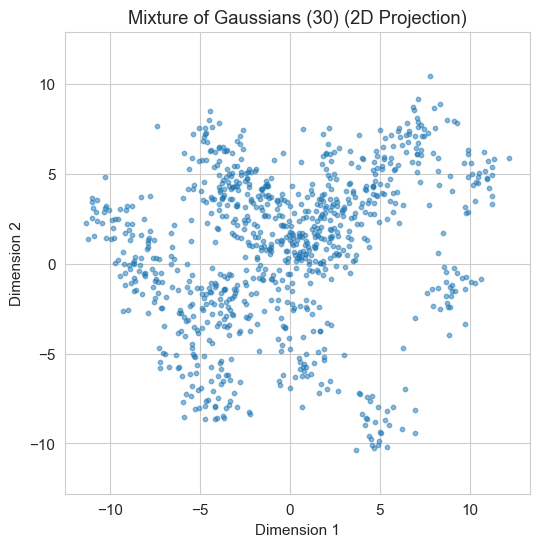

In [143]:
## plot gaussian mixture model in 2D for visualization
def plot_gaussian_mixture(model_name, sample):
    plt.figure(figsize=(6, 6))
    plt.scatter(sample[:, 0].cpu(), sample[:, 1].cpu(), alpha=0.5, s=10)
    plt.title(f"{model_name} (2D Projection)")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.axis('equal')
    plt.grid(True)

# Visualize the first two dimensions of each model's sample A
sample = generate_mixture_of_gaussians(n_samples=900, dim=2, n_components=30, separation=5, seed=1000)
plot_gaussian_mixture("Mixture of Gaussians (30)", sample)

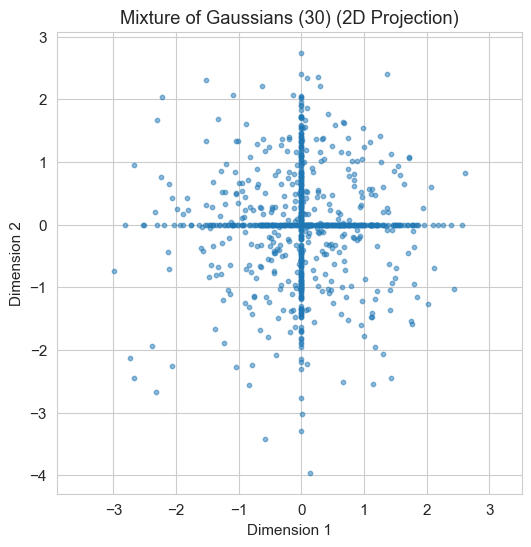

In [144]:
def plot_gaussian_mixture(model_name, sample):
    plt.figure(figsize=(6, 6))
    plt.scatter(sample[:, 0].cpu(), sample[:, 1].cpu(), alpha=0.5, s=10)
    plt.title(f"{model_name} (2D Projection)")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.axis('equal')
    plt.grid(True)

# Visualize the first two dimensions of each model's sample A
sample = generate_sparse_gaussian(n_samples=1000, dim=2, sparsity=0.4)
plot_gaussian_mixture("Mixture of Gaussians (30)", sample)

### Distance Distributions for Each Statistical Model

In [145]:
# Compute pairwise distance distributions for each model (excluding diagonal)
def compute_pairwise_distances(features):
    """
    Compute pairwise Euclidean distances and return the upper triangular part (excluding diagonal).
    """
    # Compute distance matrix
    dist_matrix = torch.cdist(features, features)
    
    # Extract upper triangular part (excluding diagonal)
    mask = torch.triu(torch.ones_like(dist_matrix), diagonal=1).bool()
    distances = dist_matrix[mask]
    
    return distances.cpu().numpy()

# Compute distances for all models
distance_distributions = {}
for model_name in models_A.keys():
    # Use sample A for distance distribution
    distances = compute_pairwise_distances(models_A[model_name])
    distance_distributions[model_name] = distances
    print(f"{model_name}: {len(distances)} pairwise distances")
    print(f"  Mean: {distances.mean():.4f}, Std: {distances.std():.4f}")
    print(f"  Min: {distances.min():.4f}, Max: {distances.max():.4f}")

Mixture of Gaussians (30): 499500 pairwise distances
  Mean: 1.2323, Std: 0.6358
  Min: 0.0000, Max: 2.0000
Mixture of Gaussians (10): 499500 pairwise distances
  Mean: 1.0287, Std: 0.6297
  Min: 0.0000, Max: 2.0000
Gaussian: 499500 pairwise distances
  Mean: 1.2736, Std: 0.6158
  Min: 0.0000, Max: 2.0000
Uniform: 499500 pairwise distances
  Mean: 1.2727, Std: 0.6174
  Min: 0.0000, Max: 2.0000
Laplacian: 499500 pairwise distances
  Mean: 1.2730, Std: 0.6168
  Min: 0.0000, Max: 2.0000
Student-t (df=3): 499500 pairwise distances
  Mean: 1.2733, Std: 0.6165
  Min: 0.0000, Max: 2.0000
Sparse Gaussian (70%): 499500 pairwise distances
  Mean: 0.8040, Std: 0.5900
  Min: 0.0000, Max: 2.0000
Sparse Gaussian (10%): 499500 pairwise distances
  Mean: 1.2687, Std: 0.6166
  Min: 0.0000, Max: 2.0000


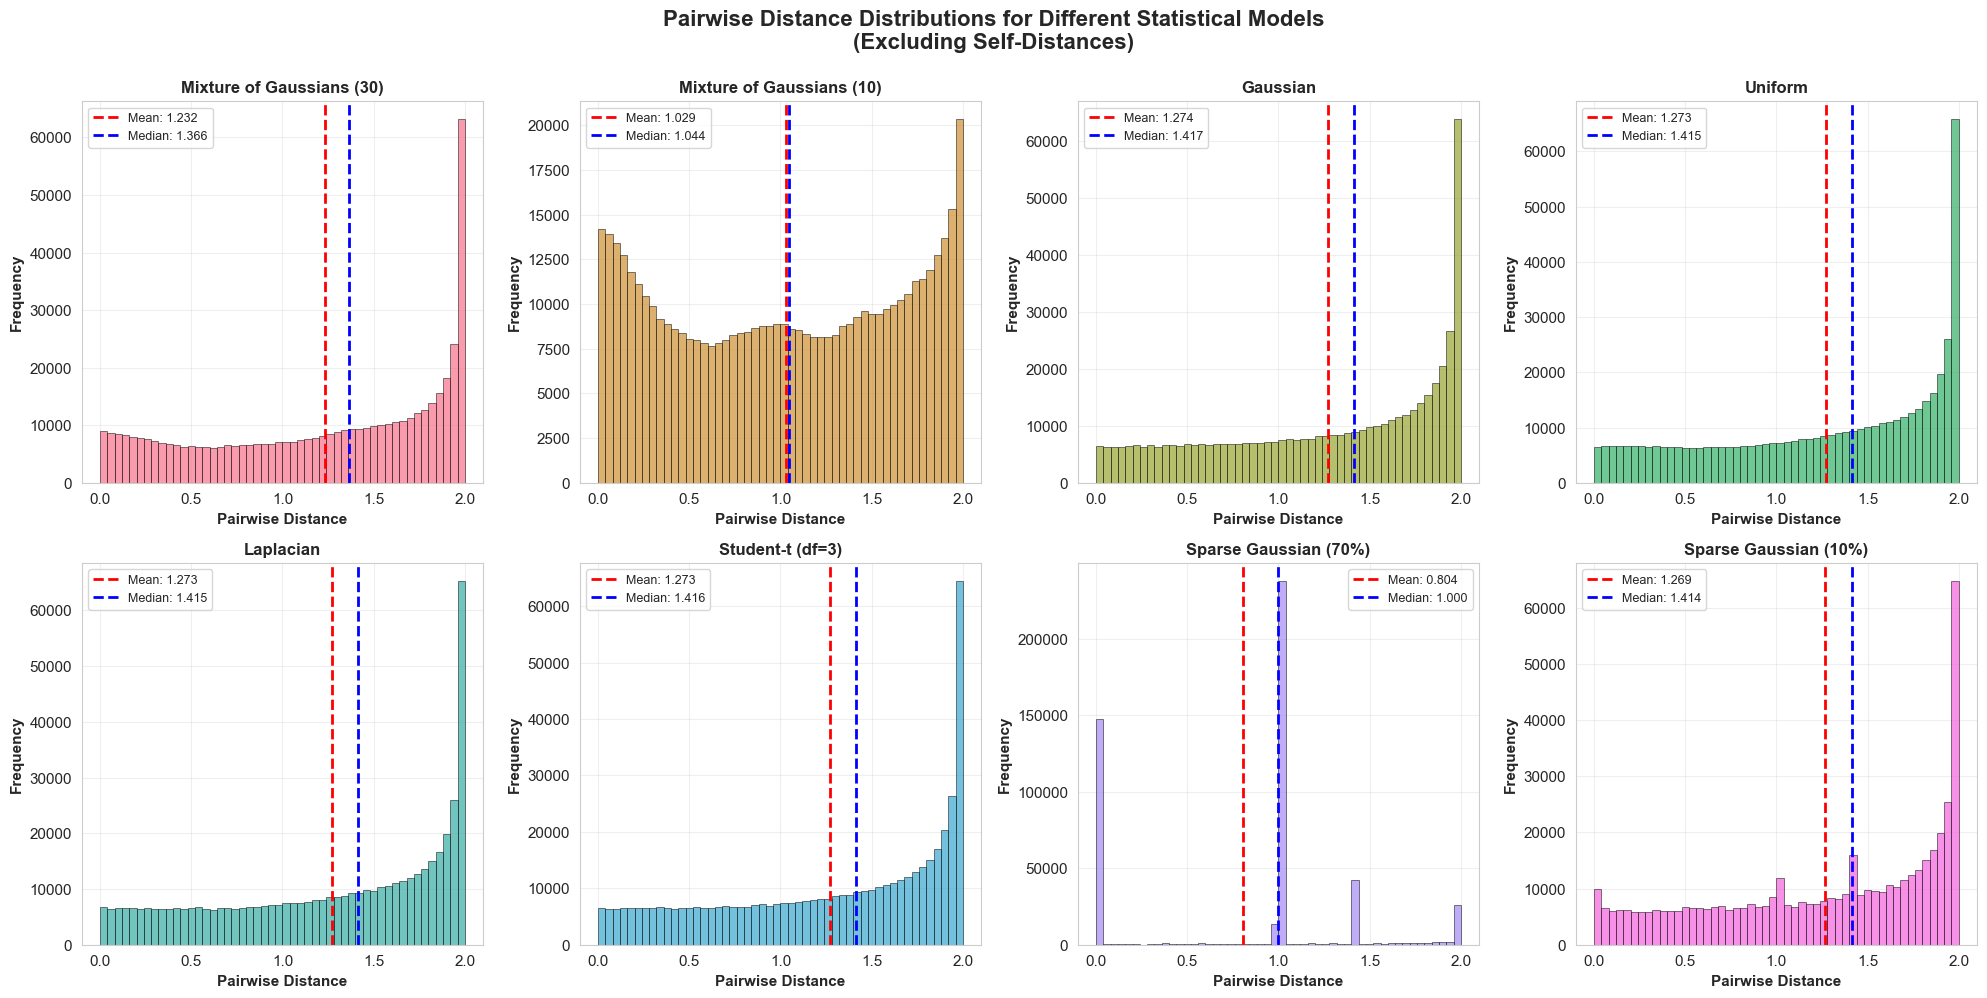

Distance distributions plot saved as 'distance_distributions.png'


In [146]:
# Plot distance distributions
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

colors = sns.color_palette('husl', n_colors=len(models_A))

for idx, (model_name, distances) in enumerate(distance_distributions.items()):
    if idx >= len(axes):
        break
    
    ax = axes[idx]
    
    # Plot histogram
    ax.hist(distances, bins=50, alpha=0.7, color=colors[idx], edgecolor='black', linewidth=0.5)
    
    # Add mean and median lines
    mean_dist = distances.mean()
    median_dist = np.median(distances)
    ax.axvline(mean_dist, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_dist:.3f}')
    ax.axvline(median_dist, color='blue', linestyle='--', linewidth=2, label=f'Median: {median_dist:.3f}')
    
    # Customize plot
    ax.set_xlabel('Pairwise Distance', fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax.set_title(model_name, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Remove extra subplots if any
for idx in range(len(distance_distributions), len(axes)):
    fig.delaxes(axes[idx])

fig.suptitle('Pairwise Distance Distributions for Different Statistical Models\n(Excluding Self-Distances)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('distance_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("Distance distributions plot saved as 'distance_distributions.png'")

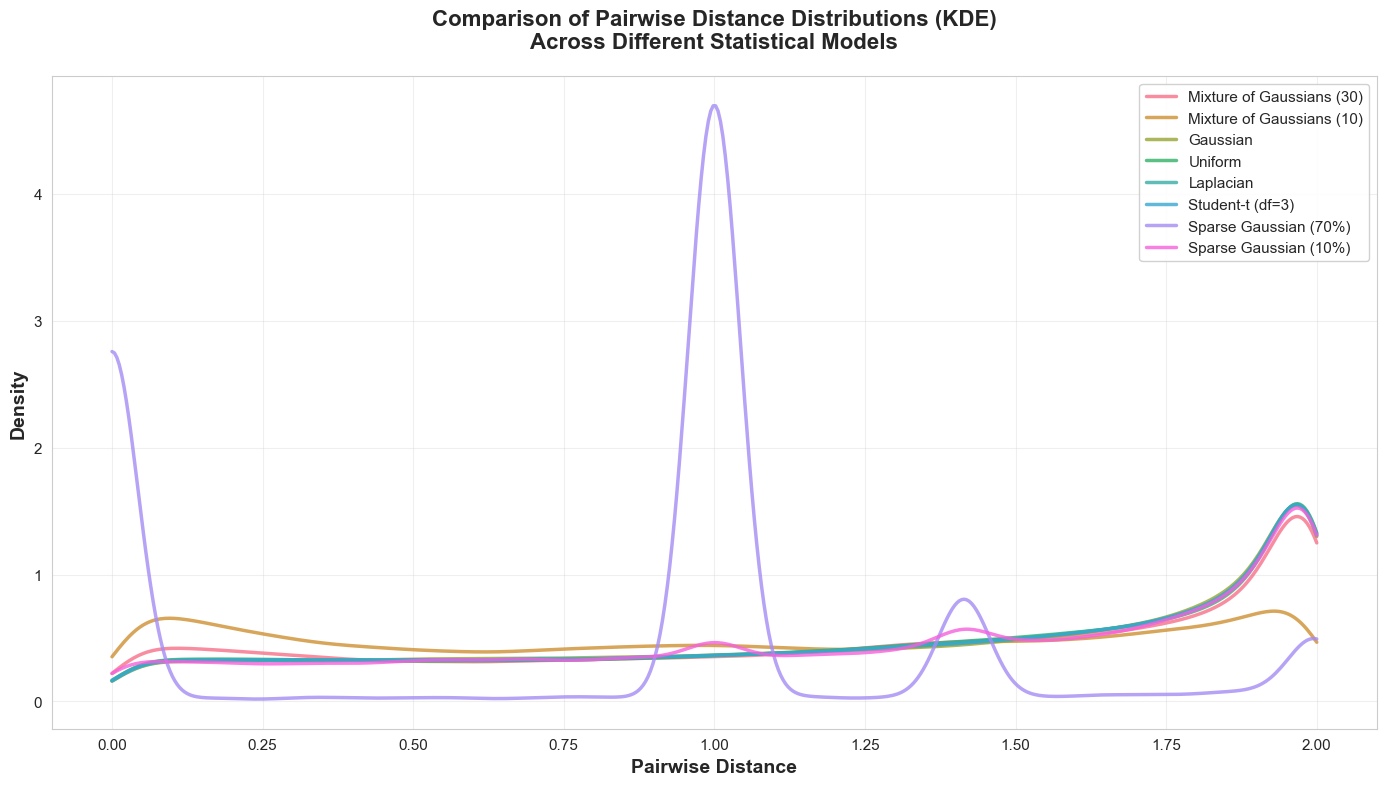

Overlay plot saved as 'distance_distributions_overlay.png'


In [147]:
# Overlay all distributions on a single plot for comparison using KDE
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(14, 8))

for (model_name, distances), color in zip(distance_distributions.items(), colors):
    # Create KDE and plot
    kde = gaussian_kde(distances)
    # Create a range of x values for plotting
    x_range = np.linspace(distances.min(), distances.max(), 500)
    density = kde(x_range)
    
    ax.plot(x_range, density, color=color, label=model_name, linewidth=2.5, alpha=0.8)
    # ax.fill_between(x_range, density, alpha=0.2, color=color)

# Customize plot
ax.set_xlabel('Pairwise Distance', fontsize=14, fontweight='bold')
ax.set_ylabel('Density', fontsize=14, fontweight='bold')
ax.set_title('Comparison of Pairwise Distance Distributions (KDE)\nAcross Different Statistical Models', 
             fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('distance_distributions_overlay.png', dpi=300, bbox_inches='tight')
plt.show()

print("Overlay plot saved as 'distance_distributions_overlay.png'")

### Distance Distribution Analysis

**Key Observations:**

- **Gaussian**: Should show a smooth, unimodal distance distribution
- **Mixture of Gaussians**: May show multi-modal distance distribution (within-cluster and between-cluster distances)
- **Uniform**: More uniform distance distribution across the range
- **Sparse Gaussian**: Different distance characteristics due to sparsity
- **Student-t & Laplacian**: Heavy-tailed distributions may show wider spread

The distance distribution is crucial because:
1. RBF kernel exp(-d²/(2σ²)) is directly affected by the distance scale
2. The median heuristic uses the median distance to set σ
3. Different distributions may have very different distance scales, affecting optimal σ values

### Compute RBF-RWKA Similarity for Different Sigma Values

In [148]:
# Store results
results = {model_name: [] for model_name in models_A.keys()}

# Compute similarity between sample A and sample B for each model
for model_name in models_A.keys():
    print(f"\nComputing RBF-RWKA for {model_name}...")
    
    feats_A = models_A[model_name]
    feats_B = models_B[model_name]
    
    for sigma in sigma_values:
        # Compare TWO INDEPENDENT samples from the same distribution
        similarity = AlignmentMetrics.rbf_rwka(
            feats_A, 
            feats_B,
            rbf_sigma=sigma,
            median=True
        )
        results[model_name].append(similarity)
    
    print(f"  Similarity range: [{min(results[model_name]):.4f}, {max(results[model_name]):.4f}]")

print("\nComputation complete!")


Computing RBF-RWKA for Mixture of Gaussians (30)...
  Similarity range: [1.0000, 1.0000]

Computing RBF-RWKA for Mixture of Gaussians (10)...
  Similarity range: [1.0000, 1.0000]

Computing RBF-RWKA for Mixture of Gaussians (10)...
  Similarity range: [1.0000, 1.0000]

Computing RBF-RWKA for Gaussian...
  Similarity range: [1.0000, 1.0000]

Computing RBF-RWKA for Gaussian...
  Similarity range: [0.0891, 1.0000]

Computing RBF-RWKA for Uniform...
  Similarity range: [0.0891, 1.0000]

Computing RBF-RWKA for Uniform...
  Similarity range: [0.0861, 1.0000]

Computing RBF-RWKA for Laplacian...
  Similarity range: [0.0861, 1.0000]

Computing RBF-RWKA for Laplacian...
  Similarity range: [0.0870, 1.0000]

Computing RBF-RWKA for Student-t (df=3)...
  Similarity range: [0.0870, 1.0000]

Computing RBF-RWKA for Student-t (df=3)...
  Similarity range: [0.0887, 1.0000]

Computing RBF-RWKA for Sparse Gaussian (70%)...
  Similarity range: [0.0887, 1.0000]

Computing RBF-RWKA for Sparse Gaussian (70%

### Plot Similarity as a Function of RBF Sigma (Globality Parameter)

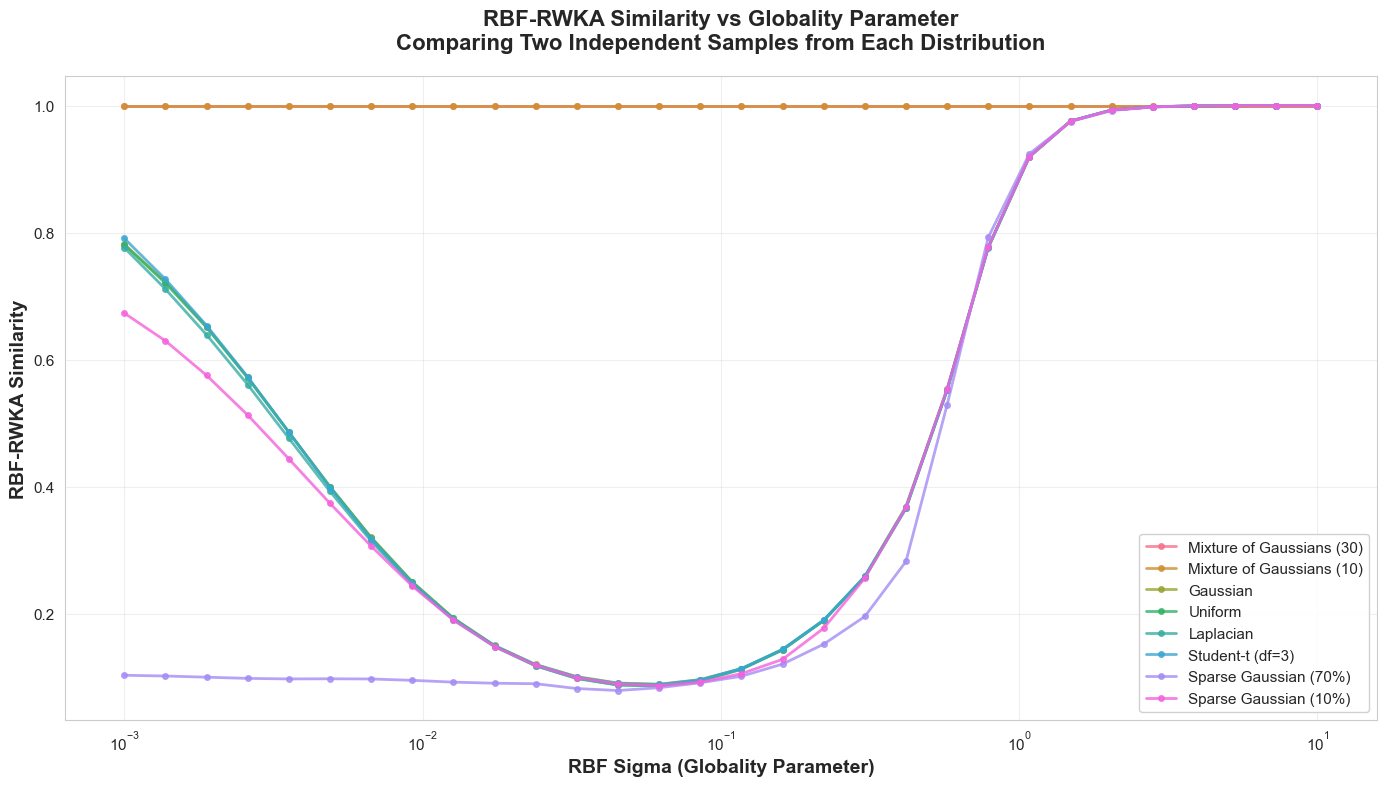

Plot saved as 'rbf_rwka_globality_analysis.png'


In [149]:
# Create the plot
fig, ax = plt.subplots(figsize=(14, 8))

# Define colors for different models
colors = sns.color_palette('husl', n_colors=len(models_A))

# Plot each model
for (model_name, similarities), color in zip(results.items(), colors):
    ax.plot(sigma_values, similarities, marker='o', markersize=4, 
            linewidth=2, label=model_name, color=color, alpha=0.8)

# Customize plot
ax.set_xlabel('RBF Sigma (Globality Parameter)', fontsize=14, fontweight='bold')
ax.set_ylabel('RBF-RWKA Similarity', fontsize=14, fontweight='bold')
ax.set_title('RBF-RWKA Similarity vs Globality Parameter\nComparing Two Independent Samples from Each Distribution', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.savefig('rbf_rwka_globality_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved as 'rbf_rwka_globality_analysis.png'")

### Cross-Model Similarity Analysis

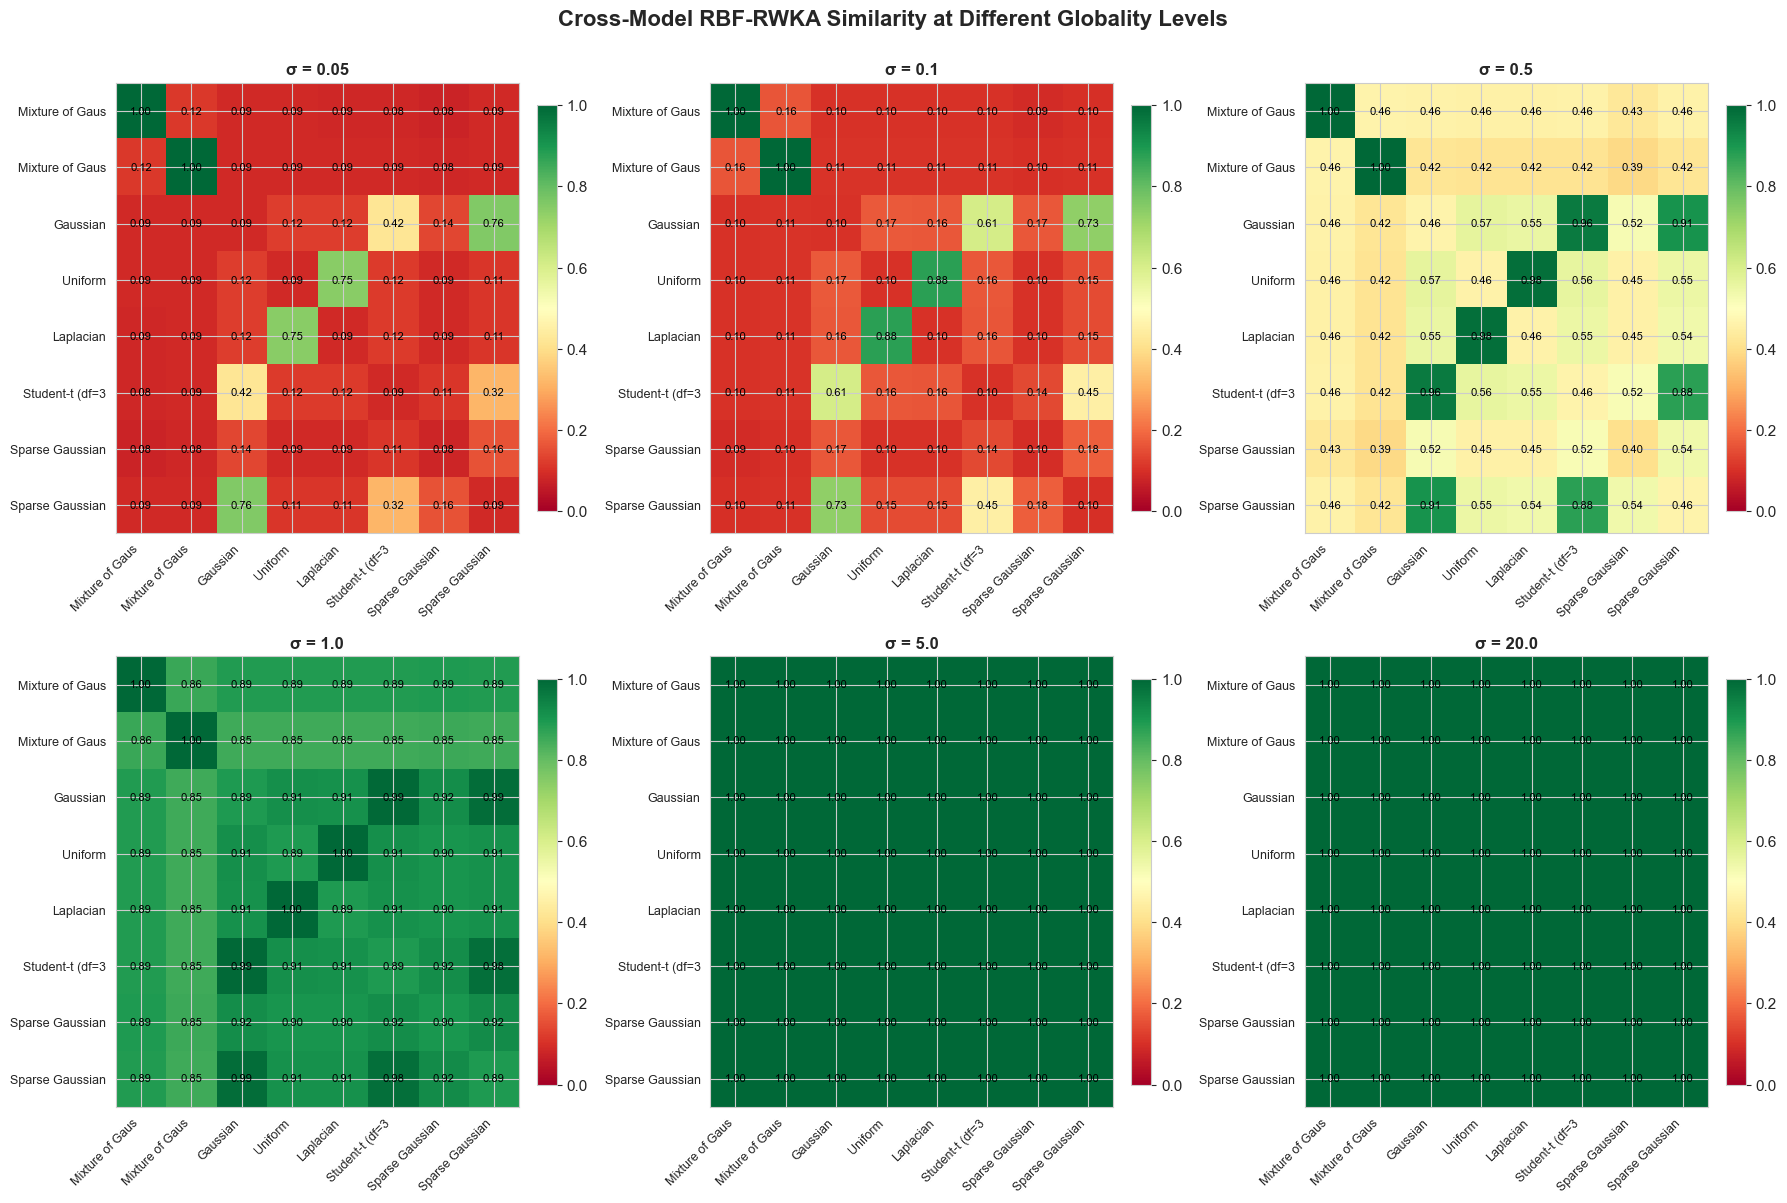

Cross-model heatmap saved as 'rbf_rwka_cross_model_heatmaps.png'


In [150]:
# Compare different models against each other
model_names = list(models_A.keys())
n_models = len(model_names)

# Select a few representative sigma values
representative_sigmas = [0.05, 0.1, 0.5, 1.0, 5.0, 20.0]

# Create subplots for different sigma values
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, sigma in enumerate(representative_sigmas):
    if idx >= len(axes):
        break
    
    ax = axes[idx]
    
    # Compute cross-model similarity matrix
    similarity_matrix = np.zeros((n_models, n_models))
    
    for i, name_i in enumerate(model_names):
        for j, name_j in enumerate(model_names):
            if i == j:
                sim = AlignmentMetrics.rbf_rwka(
                    models_A[name_i],
                    models_B[name_i],
                    rbf_sigma=sigma,
                    unbiased=False,
                    median=True)
            # Compare sample A from model i with sample A from model j
            else:
                sim = AlignmentMetrics.rbf_rwka(
                    models_A[name_i],
                    models_A[name_j],
                    rbf_sigma=sigma,
                    unbiased=False,
                    median=True
                )
            similarity_matrix[i, j] = sim
    
    # Plot heatmap
    im = ax.imshow(similarity_matrix, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(n_models))
    ax.set_yticks(range(n_models))
    ax.set_xticklabels([name[:15] for name in model_names], rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels([name[:15] for name in model_names], fontsize=9)
    ax.set_title(f'σ = {sigma}', fontsize=12, fontweight='bold')
    
    # Add text annotations
    for i in range(n_models):
        for j in range(n_models):
            text = ax.text(j, i, f'{similarity_matrix[i, j]:.2f}',
                          ha="center", va="center", color="black", fontsize=8)
    
    # Add colorbar
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Remove extra subplot
if len(representative_sigmas) < len(axes):
    fig.delaxes(axes[-1])

fig.suptitle('Cross-Model RBF-RWKA Similarity at Different Globality Levels', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('rbf_rwka_cross_model_heatmaps.png', dpi=300, bbox_inches='tight')
plt.show()

print("Cross-model heatmap saved as 'rbf_rwka_cross_model_heatmaps.png'")

### Summary Statistics

In [151]:
# Print summary statistics for each model
print("\n" + "="*80)
print("SUMMARY STATISTICS (Comparing Independent Samples from Same Distribution)")
print("="*80)

for model_name, similarities in results.items():
    similarities = np.array(similarities)
    print(f"\n{model_name}:")
    print(f"  Mean similarity: {similarities.mean():.4f}")
    print(f"  Std similarity: {similarities.std():.4f}")
    print(f"  Min similarity: {similarities.min():.4f} (at σ={sigma_values[similarities.argmin()]:.2f})")
    print(f"  Max similarity: {similarities.max():.4f} (at σ={sigma_values[similarities.argmax()]:.2f})")
    
    # Find sigma value where similarity is closest to 0.5 (middle range)
    mid_idx = np.argmin(np.abs(similarities - 0.5))
    print(f"  σ at similarity ≈ 0.5: {sigma_values[mid_idx]:.2f}")


SUMMARY STATISTICS (Comparing Independent Samples from Same Distribution)

Mixture of Gaussians (30):
  Mean similarity: 1.0000
  Std similarity: 0.0000
  Min similarity: 1.0000 (at σ=10.00)
  Max similarity: 1.0000 (at σ=0.00)
  σ at similarity ≈ 0.5: 10.00

Mixture of Gaussians (10):
  Mean similarity: 1.0000
  Std similarity: 0.0000
  Min similarity: 1.0000 (at σ=10.00)
  Max similarity: 1.0000 (at σ=0.00)
  σ at similarity ≈ 0.5: 10.00

Gaussian:
  Mean similarity: 0.5105
  Std similarity: 0.3511
  Min similarity: 0.0891 (at σ=0.06)
  Max similarity: 1.0000 (at σ=10.00)
  σ at similarity ≈ 0.5: 0.00

Uniform:
  Mean similarity: 0.5095
  Std similarity: 0.3517
  Min similarity: 0.0861 (at σ=0.06)
  Max similarity: 1.0000 (at σ=10.00)
  σ at similarity ≈ 0.5: 0.00

Laplacian:
  Mean similarity: 0.5074
  Std similarity: 0.3515
  Min similarity: 0.0870 (at σ=0.06)
  Max similarity: 1.0000 (at σ=10.00)
  σ at similarity ≈ 0.5: 0.00

Student-t (df=3):
  Mean similarity: 0.5106
  Std sim

### Interpretation

**Key Insights:**

1. **RBF Sigma (Globality Parameter)**: Controls the spatial scale of the RBF kernel
   - Small σ: More local comparisons (nearby points matter more)
   - Large σ: More global comparisons (all points contribute similarly)

2. **Expected Behavior**:
   - We're comparing TWO INDEPENDENT samples from the same distribution
   - Similarity should be < 1.0 (not perfect since samples are different)
   - Higher similarity = better ability to recognize same underlying distribution
   - Different distributions may show different sensitivity to σ
   - Clustered distributions (mixture models) may show more variation with σ

3. **Statistical Model Characteristics**:
   - **Gaussian**: Smooth, unimodal distribution
   - **Mixture of Gaussians**: Multi-modal with clear clusters
   - **Uniform**: Bounded, flat distribution
   - **Laplacian**: Peaked at center with heavier tails than Gaussian
   - **Student-t**: Heavy-tailed distribution (more outliers)
   - **Sparse Gaussian**: Most dimensions are zero (sparse representations)

4. **What to Look For**:
   - Which distributions are most sensitive to σ changes?
   - At what σ value does each distribution achieve maximum alignment?
   - How do structured distributions (mixtures) differ from unstructured ones (uniform)?